# Make Phylogeny Trees

This notebook/script constructs and visualizes phylogenetic and taxonomic hierarchy trees to summarize relationships among ASVs and abundant genera.


### Library Import

In [1]:
suppressPackageStartupMessages({

    ########### main libraries ###########
    library(SummarizedExperiment)
    library(TreeSummarizedExperiment)
    library(mia)
    library(miaViz) # mia visualizatioon
    library(vegan) # ecol stats?

    
    ########### data manipulation tools ###########
    library(tidyverse)
    
    ########### visualization libraries ###########   
    library(ggpubr)
    library(pheatmap)
    library(readr)
    library(RColorBrewer)
    library(colorspace)
    library(cowplot)
    library(grid)
    library(patchwork)
    library(gridExtra)
    library(ggrepel)
    library(ggpubr)
    library(ggthemes)
    library(RColorBrewer)
    library(patchwork)
    library(cowplot)
    library(scater)
    
    ########### resource management tools ###########
    # library(tictoc)

    
    ################ notes ####################
    ### loaded by tidyverse
    # library(ggplot2)
    # library(tidyr)
    # library(dplyr)
    # library(readr)
    # library(stringr)
})



warnLevel <- getOption('warn')
options(warn = -1)



### Arguments Piped in with R script Conversion

In [2]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [3]:
TAXA_DIR <- file.path(PROJECT_DIR, "taxonomy_assignment")
tse_rds_file <- file.path(TAXA_DIR, paste0(PROJECT_NAME, ".ASV_with_taxa.TSE.rds"))


In [4]:
# read rds file
tse <- readRDS(tse_rds_file)


In [5]:
# tse

### Make Output Directory

In [7]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
PHYLO_DIR <- file.path(FIG_DIR, "phylo")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_PHYLO_DIR <- file.path(FIG_DIR, "phylo")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(PHYLO_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_PHYLO_DIR, recursive = TRUE, showWarnings = FALSE)

## Analysis 

### Make genus level TSE object

Making a phylogenetic tree doesn't work correctly unless I aggregate to genus level data

In [8]:
tse_genus <- agglomerateByRank(
    tse,
    rank = "Genus",
    update.tree = FALSE
)

tse_genus

class: TreeSummarizedExperiment 
dim: 163 29 
metadata(1): agglomerated_by_rank
assays(1): counts
rownames(163): [Bacteroides] pectinophilus group [Eubacterium] eligens
  group ... Weissella Xylanibacter
rowData names(6): Kingdom Phylum ... Family Genus
colnames(29): 10BF 10EU ... 8EU 9BF
colData names(26): group run_id ... final_read_depth observed_ASVs
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
rowLinks: NULL
rowTree: NULL
colLinks: NULL
colTree: NULL

In [128]:
tse_genus <- addHierarchyTree(tse_genus)

In [131]:
# getTaxonomyRanks()

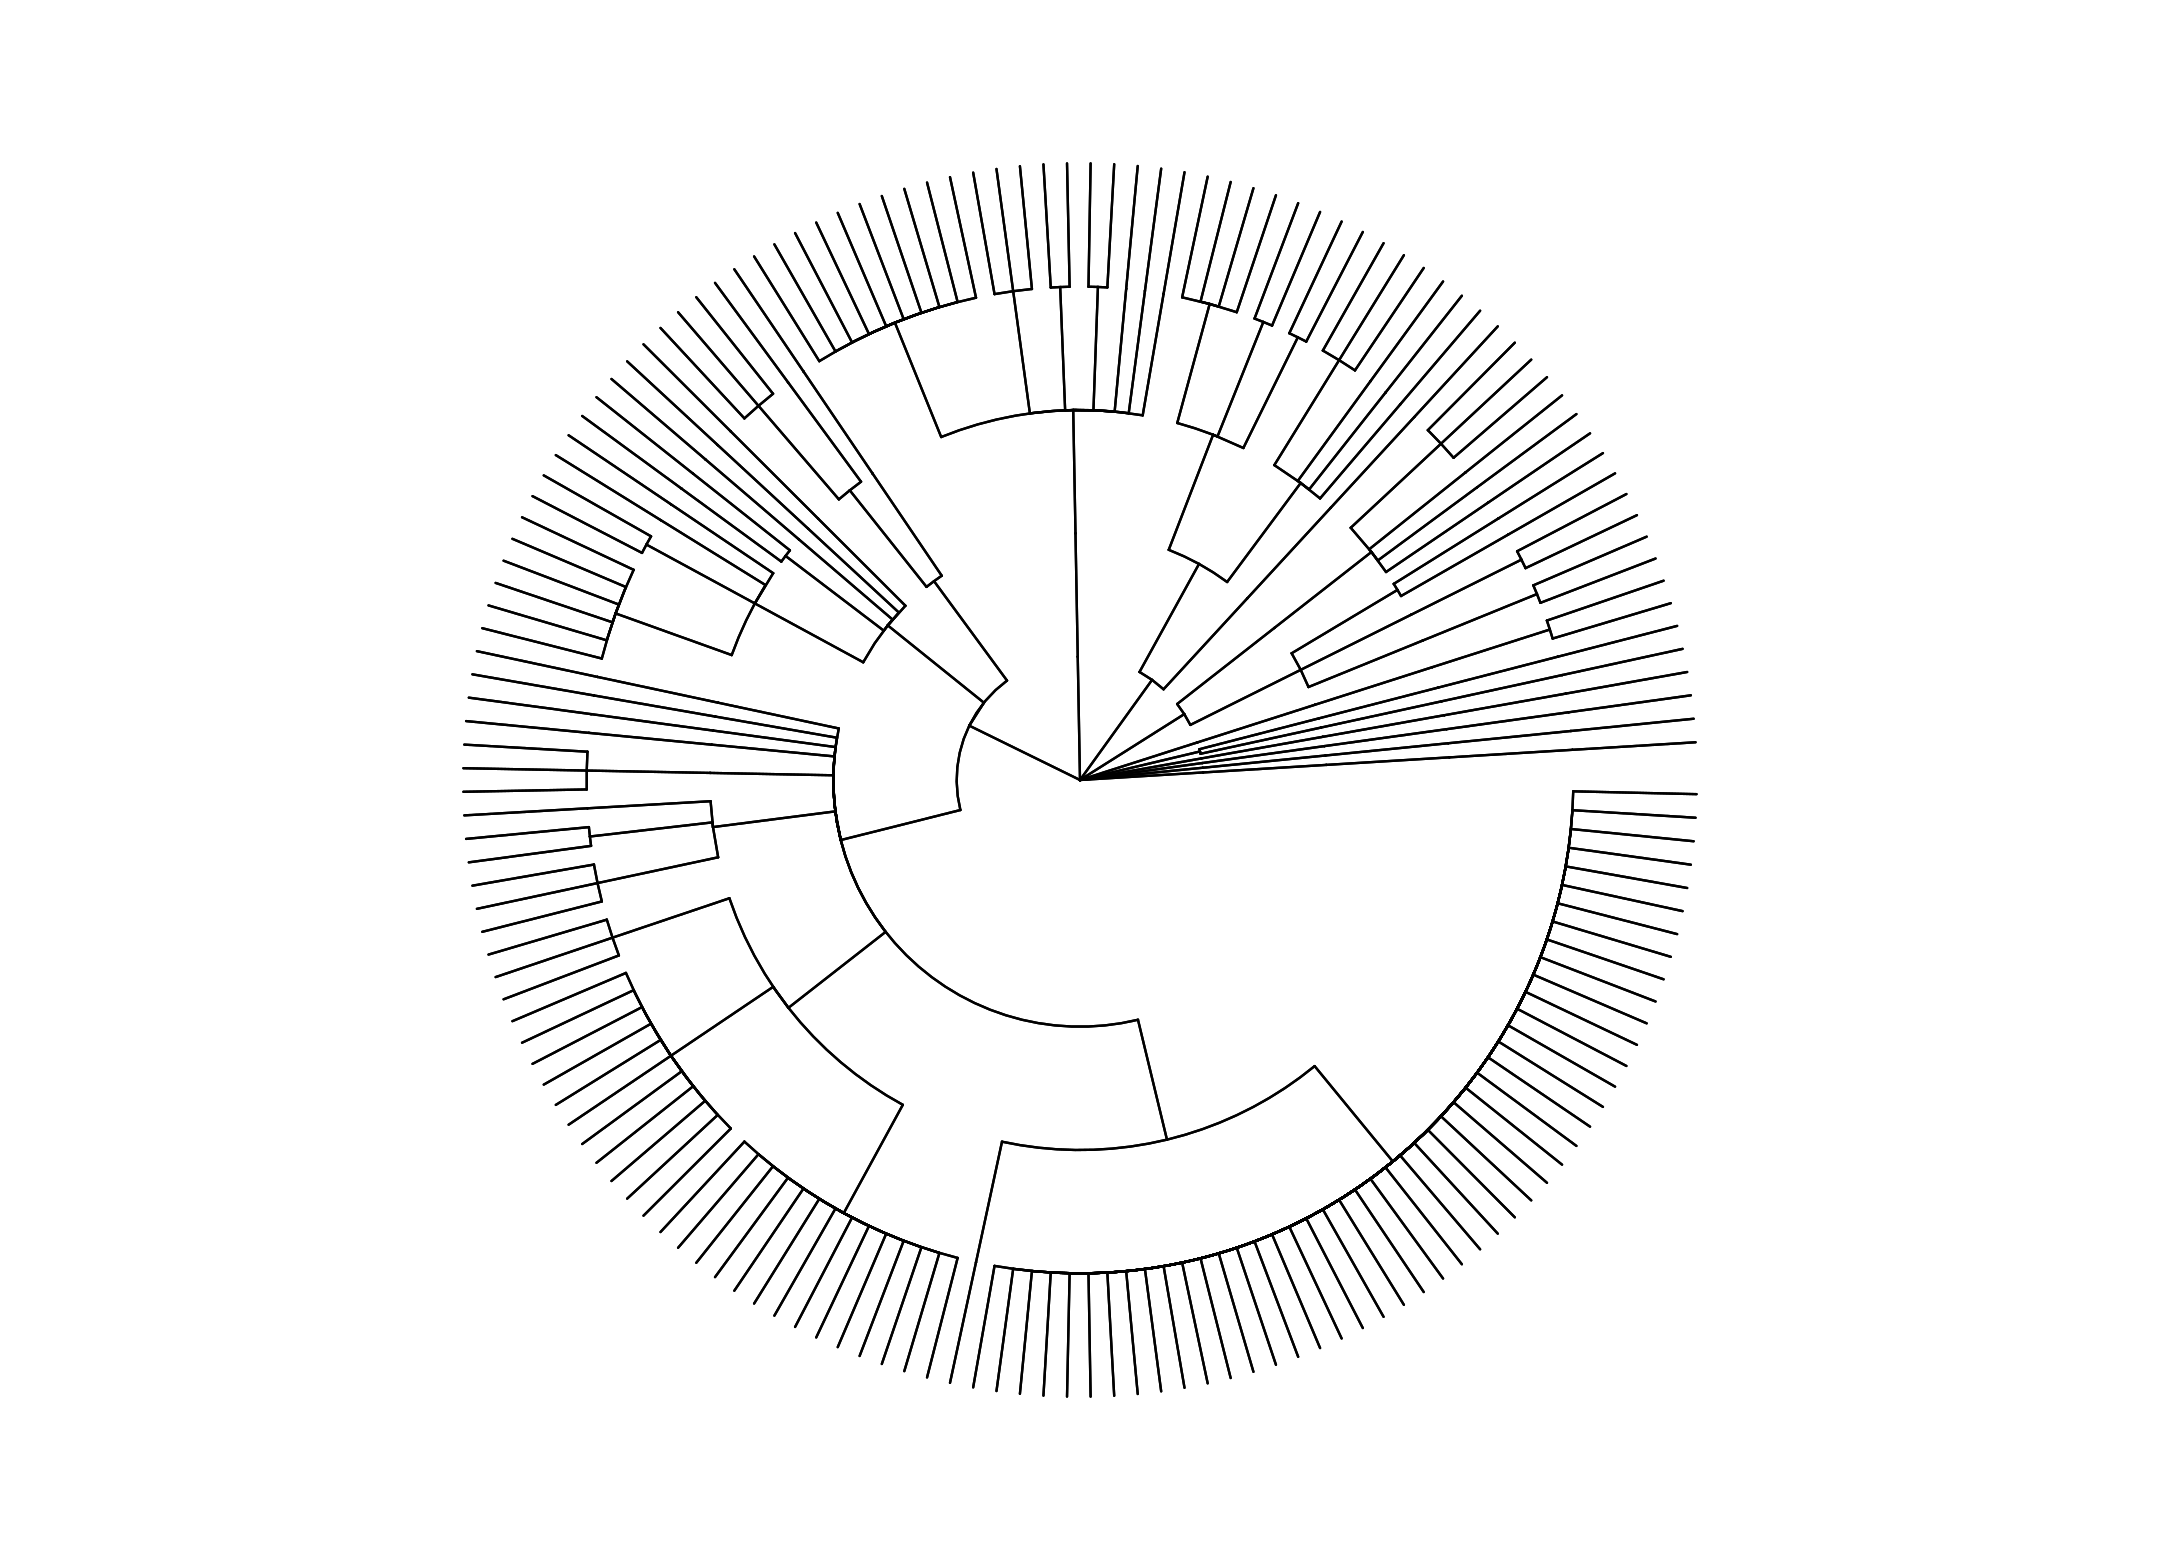

In [130]:
# test plot row tree 
plotRowTree(tse_genus)

In [51]:
# top 50 features
top <- getTop(tse_genus, top = 50L)

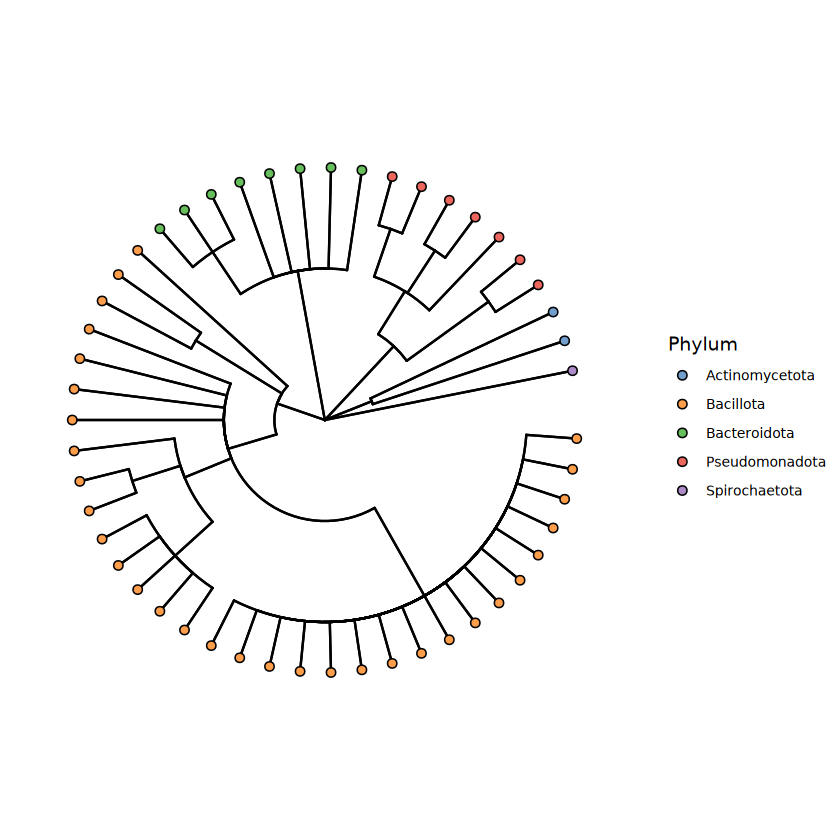

In [53]:
# Plot
plotRowTree(
    tse_genus[top, ],
    tip.colour.by = "Phylum"
)

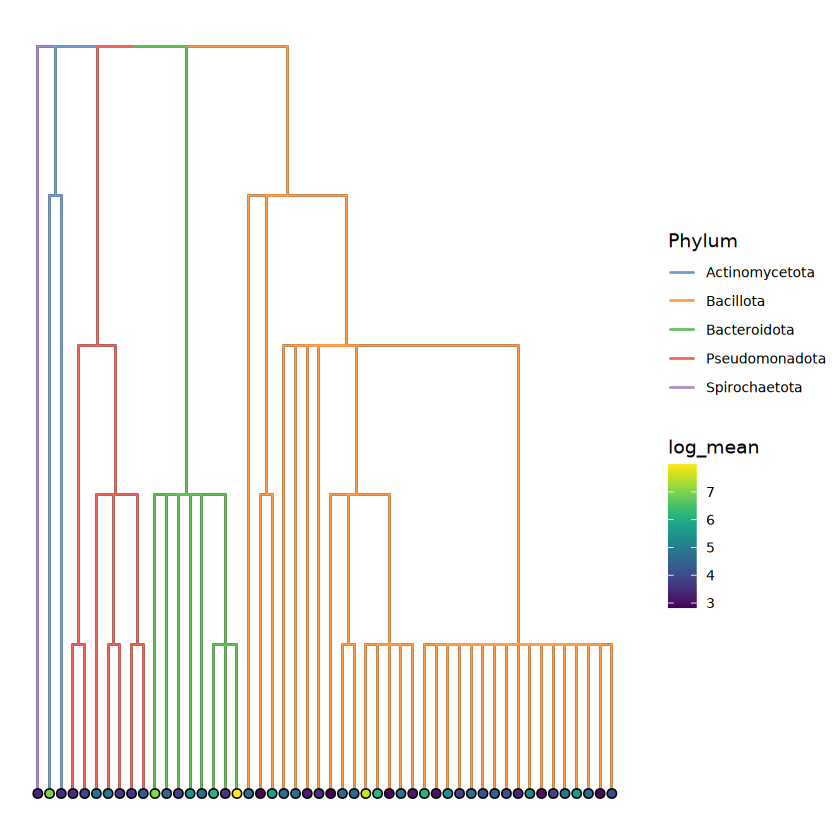

In [54]:
# Calculate mean abundance
tse_genus <- addPerFeatureQC(tse_genus)
rowData(tse_genus)[["log_mean"]] <- log(rowData(tse_genus)[["mean"]])

# basic dendrogram
# # Plot
# plotRowTree(
#     tse_genus[top, ],
#     layout = "dendrogram",
#     edge.colour.by = "Phylum",
#     tip.colour.by = "log_mean"
# )


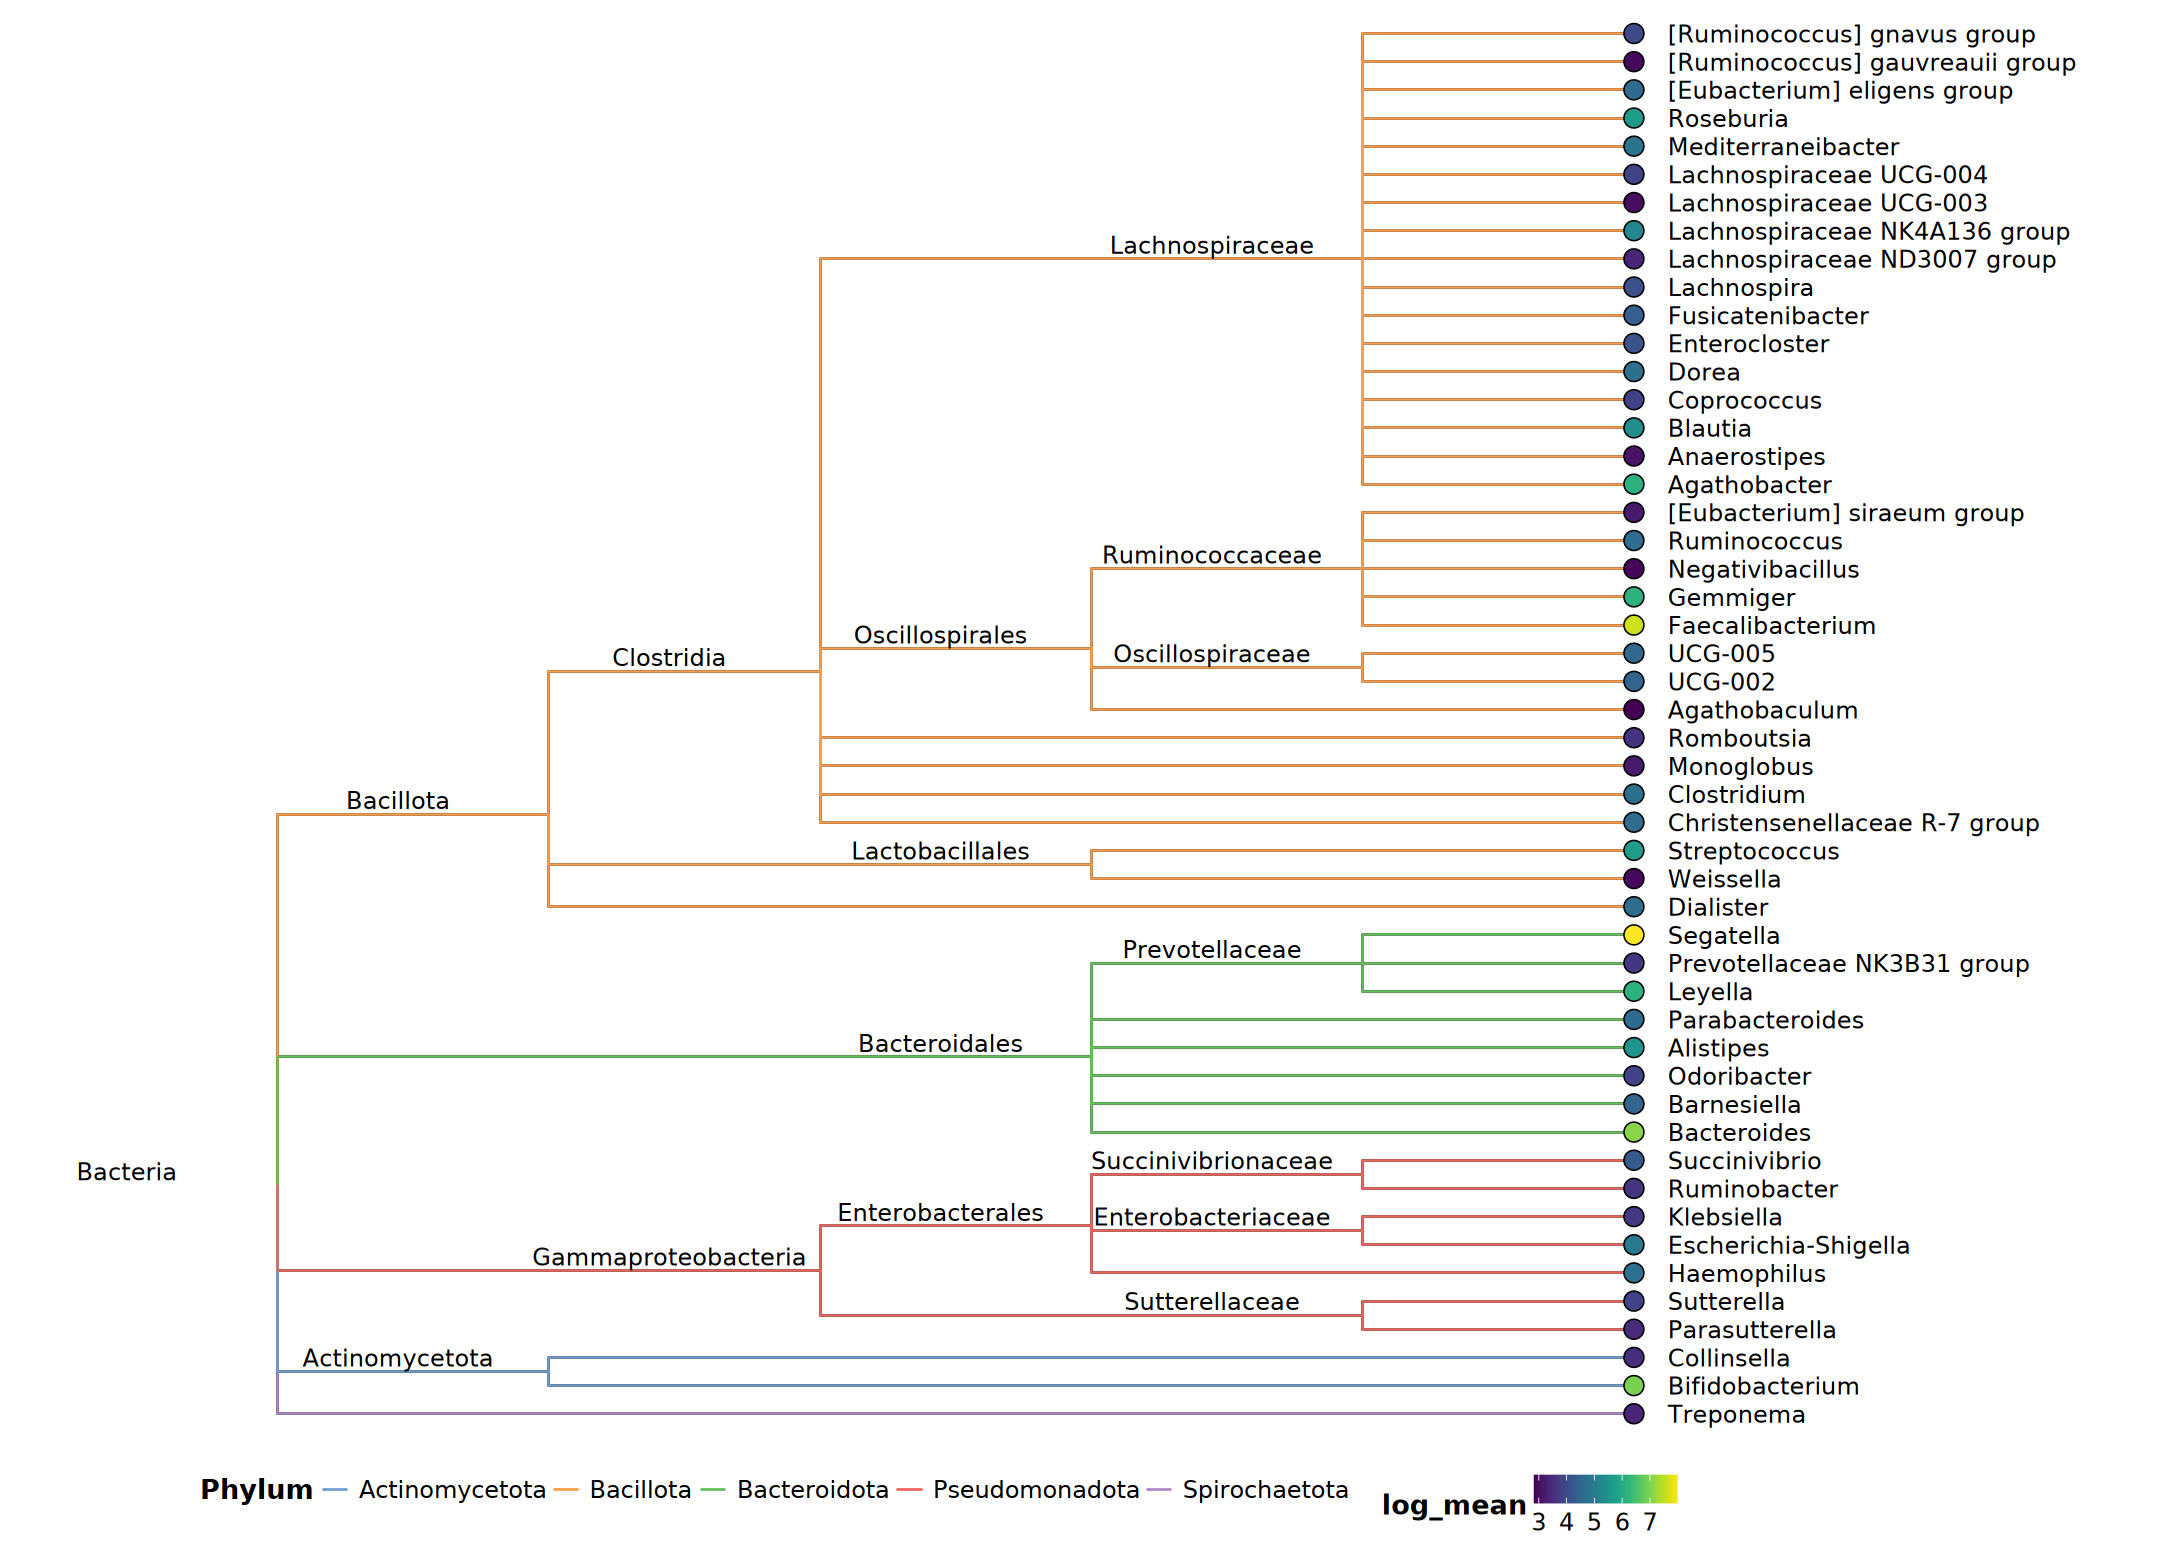

In [114]:
options(repr.plot.width = 18, repr.plot.height = 13)

p <- plotRowTree(
    tse_genus[top, ],
    layout = "rectangular",
    edge.colour.by = "Phylum",
    tip.colour.by = "log_mean",
    show.label = TRUE,
    relabel.tree = TRUE,
    levels.rm = TRUE
)

# Increase the interactive text layer sizes
p$layers[[5]]$aes_params$size <- 5 # changes dots 
p$layers[[6]]$aes_params$size <- 5 # changes leaves
p$layers[[7]]$aes_params$size <- 5 # changes branches
p$layers[[7]]$position <- position_nudge(y = 0.5, x = -0.058)

p <- p +
    coord_cartesian(clip = "off") +
    theme(
        legend.position = "bottom",
        legend.text = element_text(size = 14),
        legend.title = element_text(size = 16, face = "bold"),
        legend.box.margin = margin(
            t = 10,
            r = 0,
            b = 0,
            l = 50 # space on LEFT of legend = pushes legend right
        ) ,
        # Actual space outside panel for labels to spill into
        plot.margin = margin(
            t = 10,
            r = 250,
            b = 10,
            l = 30
        )
    )

p

In [120]:
ggsave(
    filename = paste0(FIG_PHYLO_DIR, '/', 'genus_taxonomy_tree.png'),
    plot = p,
    width = 16.4,
    height = 11,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_PHYLO_DIR, '/', 'genus_taxonomy_tree.pdf'),
    plot = p,
    width = 15,
    height = 11,
    units = "in",
    bg = "white"
)